# 05 — Performance prédictive (statistique + économique) des 3 modèles

**Portée** : PR-AUC, courbe de calibration, matrice de confusion, XPER (décomposition de
l'AUC par feature), et optimisation économique du seuil de décision (P&L). **Pas de Brier
score ni de log-loss** — non couverts par le cours ISAF, écartés volontairement (pas un
oubli).

**Sources des prédictions** :
- Logit, XGBoost : `models/logit.joblib`, `models/xgb.joblib`, rechargés et appliqués
  directement.
- TabICL : `data/tabicl_predictions.parquet` — prédictions déjà calculées sur Colab, **jamais
  de rechargement/refit du modèle en local** (`TabICLClassifier.fit()` segfault de façon
  reproductible sur cette machine, voir `docs/soutenance_notes.md` "TabICL — diagnostic du
  crash CPU et décision").

Toute la logique réutilisable vit dans `src/performance.py` (importé ici, jamais dupliqué).
Les calculs les plus longs (XPER, grilles de seuils par GroupKFold) ont été pré-calculés via
`run_full_analysis()` et sauvegardés dans `reports/performance/` — ce notebook charge ces
résultats pour la narration plutôt que de tout relancer à chaque exécution (XPER à 156-158
features prend plusieurs minutes par modèle).


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.performance import (
    load_model_predictions, split_train_test, load_economic_assumptions,
    pr_auc, calibration_table, confusion_metrics, calculate_pnl,
    MODEL_NAMES, ROOT,
)

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100
REPORTS_DIR = ROOT / "reports" / "performance"

MODEL_LABELS = {"logit": "Logit", "xgb": "XGBoost", "tabicl": "TabICL"}


## Chargement

`load_model_predictions()` recharge `data/clean.parquet`, applique `logit.joblib`/`xgb.joblib`,
et joint les prédictions TabICL pré-calculées — une seule fonction, réutilisée par le script et
ce notebook (`src/performance.py`).


In [2]:
data, feature_dict = load_model_predictions()
train, test, split = split_train_test(data)
proba_cols = {"logit": "proba_logit", "xgb": "proba_xgb", "tabicl": "proba_tabicl"}

print(f"train: {train.shape} | test: {test.shape}")
print(f"features (xgb/tabicl): {len(feature_dict['features'])} | "
      f"features_logit: {len(feature_dict['features_logit'])}")
data[["proba_logit", "proba_xgb", "proba_tabicl"]].describe()


train: (6542, 171) | test: (1826, 171)
features (xgb/tabicl): 158 | features_logit: 156


,proba_logit,proba_xgb,proba_tabicl
count,8368.000000,8368.000000,8368.000000
mean,0.420270,0.418112,0.416407
std,0.197807,0.229603,0.225682
min,0.018078,0.007434,0.007071
25%,0.263412,0.223794,0.234757
50%,0.405980,0.389509,0.399265
75%,0.563659,0.596442,0.577826
max,0.954905,0.984436,0.989319


## Partie 1 — Performance statistique, au-delà de l'AUC

### 1.1 Precision-Recall AUC (average precision)

Complète l'AUC (ROC) par une lecture plus informative quand la classe positive n'est pas à 50%
(`dec=1` ~42%) : la PR-AUC se concentre sur la qualité des recommandations positives, pas sur la
discrimination globale.


In [3]:
pr_auc_results = {name: pr_auc(test["dec"], test[proba_cols[name]]) for name in MODEL_NAMES}
pd.Series(pr_auc_results, name="PR-AUC").round(4).to_frame()


,PR-AUC
logit,0.5042
xgb,0.5062
tabicl,0.5445


### 1.2 Courbe de calibration

Probabilité prédite moyenne vs taux réel observé, par bins de proba prédite (10 bins). Un modèle
bien calibré doit avoir `mean_predicted ≈ observed_rate` dans chaque bin — pertinent puisqu'on
utilise ensuite un seuil de décision fixe sur ces probabilités (partie 3).


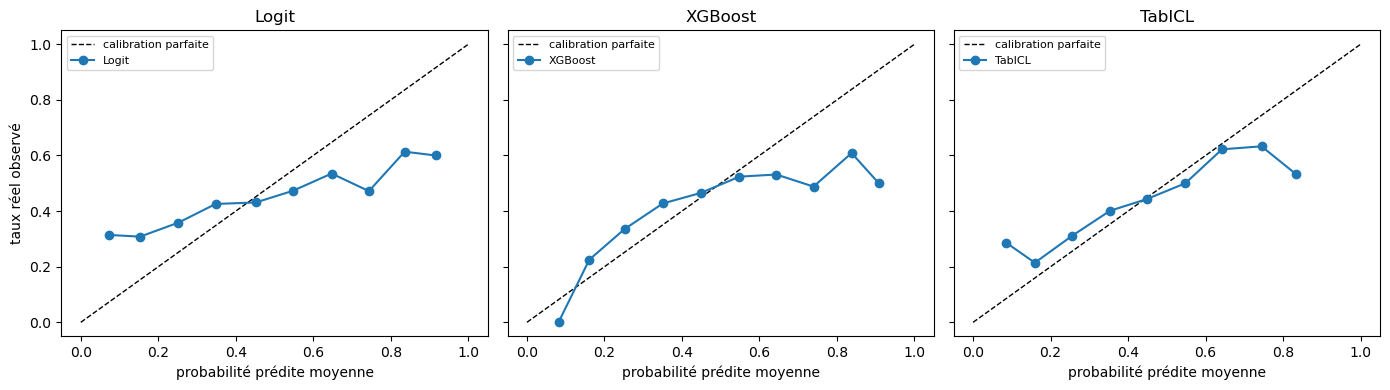

,bin,bin_range,n,mean_predicted,observed_rate
0,0,"[0.00, 0.10)",70,0.071950,0.314286
1,1,"[0.10, 0.20)",211,0.152931,0.308057
2,2,"[0.20, 0.30)",304,0.252071,0.358553
3,3,"[0.30, 0.40)",289,0.347995,0.425606
4,4,"[0.40, 0.50)",290,0.451622,0.431034
5,5,"[0.50, 0.60)",222,0.547350,0.472973
6,6,"[0.60, 0.70)",200,0.647389,0.535000
7,7,"[0.70, 0.80)",142,0.743453,0.471831
8,8,"[0.80, 0.90)",88,0.835807,0.613636
9,9,"[0.90, 1.00)",10,0.915421,0.600000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
calibration_tables = {}
for ax, name in zip(axes, MODEL_NAMES):
    calib = calibration_table(test["dec"], test[proba_cols[name]])
    calibration_tables[name] = calib
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="calibration parfaite")
    ax.plot(calib["mean_predicted"], calib["observed_rate"], "o-", label=MODEL_LABELS[name])
    ax.set_title(MODEL_LABELS[name])
    ax.set_xlabel("probabilité prédite moyenne")
    ax.legend(fontsize=8)
axes[0].set_ylabel("taux réel observé")
plt.tight_layout()
plt.show()

calibration_tables["logit"]


## Partie 3 — Optimisation économique (avant la matrice de confusion de la partie 1,
pour disposer du seuil optimal)

### Hypothèses économiques

Chargées depuis `data/economic_assumptions.json` — **aucune valeur X/Y en dur dans le code**,
tout passe par ce fichier.


In [5]:
assumptions = load_economic_assumptions()
X, Y = assumptions["X"], assumptions["Y"]
print(f"X (gain d'un oui recommandé) = {X} €")
print(f"Y (coût d'un non recommandé) = {Y} €")
print(f"Note : {assumptions['note']}")


X (gain d'un oui recommandé) = 2 €
Y (coût d'un non recommandé) = 0.5 €
Note : gain d'un oui recommandé vs coût d'un non recommandé, en euros. Hypothèse de départ (ratio 4:1), à affiner : un profil recommandé qui aboutit à un 'oui' contribue à une interaction positive (satisfaction, rétention, conversion premium potentielle). Une recommandation 'gâchée' coûte beaucoup moins : l'utilisateur passe au profil suivant. Ratio qualitatif, non mesuré -- recherche de valeurs plus réalistes en cours.


### P&L individuel

`calculate_pnl(y_true, y_pred_proba, threshold, X, Y)` : **+X** si le profil est recommandé
(`proba > threshold`) ET `dec == 1` ; **−Y** si recommandé ET `dec == 0` ; **0** sinon.

**Simplification assumée** (documentée dans `src/performance.py` et `docs/soutenance_notes.md`) :
calculé au niveau de la décision **individuelle** (`dec`), pas du vrai match mutuel (`match` =
A ET B disent oui) — croiser deux décisions d'une même paire sortirait du cadre "un score, une
recommandation". "Match manqué" devient ici "occasion de oui manquée" au niveau individuel : pas
de coût d'opportunité modélisé pour un `dec=1` non recommandé dans cette version.

### Grille de seuils (0.05 à 0.95, pas 0.05), optimisée sur TRAIN via GroupKFold (5 folds sur wave)

**Limite pour TabICL** : contrairement à logit/xgb (vraiment ré-entraînés à chaque fold), TabICL
ne peut pas être ré-entraîné en local — l'optimisation réutilise les prédictions déjà figées
(un seul entraînement complet), restreintes aux indices de validation de chaque fold. Moins
rigoureux, documenté explicitement.


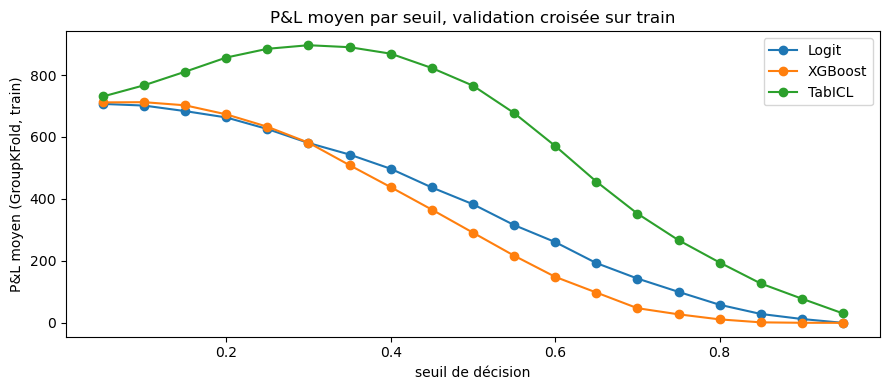

In [6]:
threshold_results = {}
for name in MODEL_NAMES:
    grid = pd.read_csv(REPORTS_DIR / f"threshold_grid_{name}.csv")
    threshold_results[name] = grid

fig, ax = plt.subplots(figsize=(9, 4))
for name in MODEL_NAMES:
    grid = threshold_results[name]
    ax.plot(grid["threshold"], grid["mean_pnl"], "o-", label=MODEL_LABELS[name])
ax.set_xlabel("seuil de décision")
ax.set_ylabel("P&L moyen (GroupKFold, train)")
ax.legend()
ax.set_title("P&L moyen par seuil, validation croisée sur train")
plt.tight_layout()
plt.show()


In [7]:
summary = pd.read_csv(REPORTS_DIR / "summary_3_models.csv")
summary[["model", "optimal_threshold", "pnl_test_optimal", "pnl_test_default_05"]]


,model,optimal_threshold,pnl_test_optimal,pnl_test_default_05
0,logit,0.05,1042.0,516.5
1,xgb,0.10,1051.0,507.5
2,tabicl,0.30,947.0,498.0


Le seuil optimal (trouvé sur train, jamais sur test) est appliqué **une seule fois** sur le test
set, comparé au P&L à seuil naïf 0.5 — le test set n'est touché qu'à ce moment précis, cohérent
avec l'architecture de validation du projet (voir `docs/soutenance_notes.md`).


### Retour Partie 1.3 — Matrice de confusion au seuil optimal

Accuracy / precision / recall / F1, au seuil optimal trouvé ci-dessus (pas à 0.5).


In [8]:
confusion_rows = []
for name in MODEL_NAMES:
    t = summary.loc[summary["model"] == name, "optimal_threshold"].iloc[0]
    m = confusion_metrics(test["dec"], test[proba_cols[name]], t)
    m["model"] = name
    confusion_rows.append(m)
pd.DataFrame(confusion_rows)[["model", "threshold", "accuracy", "precision", "recall", "f1",
                              "tn", "fp", "fn", "tp"]]


,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,logit,0.05,0.430997,0.429515,0.996169,0.600231,7,1036,3,780
1,xgb,0.10,0.435926,0.431881,1.000000,0.603236,13,1030,0,783
2,tabicl,0.30,0.537240,0.477306,0.832695,0.606794,329,714,131,652


## Partie 2 — XPER sur l'AUC

Décomposition de l'AUC par feature (Sinclair et al.) — identifie les features qui contribuent
le plus à la capacité de discrimination du modèle, contrairement à une importance générique
(gain XGBoost, coefficients logit) qui n'est pas directement comparable entre modèles.

**TabICL** : non calculable en local (nécessite le vrai objet modèle, appelé des milliers de
fois sur des coalitions de features masquées — pas juste des prédictions figées). Tenté sur
Colab via `colab/xper_tabicl.py` avec des paramètres réduits — voir le statut ci-dessous.


In [9]:
xper_results = {}
for name in ["logit", "xgb"]:
    xper_results[name] = pd.read_csv(REPORTS_DIR / f"xper_values_{name}.csv")
    print(f"--- Top 10 XPER, {MODEL_LABELS[name]} ---")
    print(xper_results[name].head(10).to_string(index=False))
    print()


--- Top 10 XPER, Logit ---
     feature  xper_value  abs_xper_value
career_c_A_4   -0.020402        0.020402
   fit_score    0.018881        0.018881
  exphappy_A    0.017715        0.017715
    amb1_1_B    0.014647        0.014647
   attr3_1_B   -0.014140        0.014140
    go_out_B    0.013353        0.013353
   reading_B    0.012223        0.012223
   attr1_1_B    0.012212        0.012212
   attr1_1_A    0.012160        0.012160
    sports_A   -0.011334        0.011334

--- Top 10 XPER, XGBoost ---
      feature  xper_value  abs_xper_value
     sports_B    0.074947        0.074947
career_c_B_16    0.074484        0.074484
field_cd_B_NA    0.074484        0.074484
     goal_A_2    0.074265        0.074265
   imprelig_A    0.054276        0.054276
     gaming_A   -0.048902        0.048902
career_c_B_15   -0.044438        0.044438
field_cd_A_17    0.044415        0.044415
    attr3_1_B    0.042704        0.042704
career_c_A_14    0.041965        0.041965



**Lien avec la fairness (Max)** : on vérifie explicitement si `income_A`/`income_B` — déjà
identifiées comme proxy géographique potentiel de `race_A`/`cand_race` (ANOVA, voir
`docs/soutenance_notes.md`) — apparaissent parmi les features à forte contribution XPER.


In [10]:
for name in ["logit", "xgb"]:
    top = xper_results[name].head(10)
    income_in_top = top[top["feature"].str.contains("income", case=False)]
    print(f"{MODEL_LABELS[name]} : income_A/B dans le top 10 XPER -> "
          f"{'OUI : ' + ', '.join(income_in_top['feature']) if len(income_in_top) else 'non'}")


Logit : income_A/B dans le top 10 XPER -> non
XGBoost : income_A/B dans le top 10 XPER -> non


## Test de robustesse : scénarios économiques alternatifs

Refait l'optimisation de seuil pour deux scénarios alternatifs (X=1/Y=1, X=3/Y=0.3), en
réécrivant **temporairement** `data/economic_assumptions.json` à chaque scénario puis en
restaurant les valeurs d'origine (`run_robustness_test`, avec `try`/`finally`) — jamais de
valeur X/Y en dur dans le code, même pour ce test.


In [11]:
robustness = pd.read_csv(REPORTS_DIR / "robustness_test.csv")
robustness


,scenario,X,Y,model,optimal_threshold,pnl_test_at_optimal
0,X=1/Y=1,1,1.0,logit,0.60,28.0
1,X=1/Y=1,1,1.0,xgb,0.60,17.0
2,X=1/Y=1,1,1.0,tabicl,0.45,55.0
3,X=3/Y=0.3,3,0.3,logit,0.05,2029.2
4,X=3/Y=0.3,3,0.3,xgb,0.05,2036.1
5,X=3/Y=0.3,3,0.3,tabicl,0.25,1909.5


**Le classement des 3 modèles et l'ordre de grandeur du seuil optimal changent-ils entre
scénarios ?** À lire directement dans le tableau ci-dessus : comparer `optimal_threshold` et le
classement par `pnl_test_at_optimal` entre les 3 scénarios (X=2/Y=0.5 d'origine, X=1/Y=1,
X=3/Y=0.3).


In [12]:
pivot_threshold = robustness.pivot(index="model", columns="scenario", values="optimal_threshold")
pivot_pnl = robustness.pivot(index="model", columns="scenario", values="pnl_test_at_optimal")
print("Seuil optimal par scénario :")
print(pivot_threshold.to_string())
print("\nP&L test au seuil optimal, par scénario :")
print(pivot_pnl.to_string())
print("\nClassement des modèles par scénario (meilleur P&L en premier) :")
for col in pivot_pnl.columns:
    print(f"  {col} : {pivot_pnl[col].sort_values(ascending=False).index.tolist()}")


Seuil optimal par scénario :
scenario  X=1/Y=1  X=3/Y=0.3
model                       
logit        0.60       0.05
tabicl       0.45       0.25
xgb          0.60       0.05

P&L test au seuil optimal, par scénario :
scenario  X=1/Y=1  X=3/Y=0.3
model                       
logit        28.0     2029.2
tabicl       55.0     1909.5
xgb          17.0     2036.1

Classement des modèles par scénario (meilleur P&L en premier) :
  X=1/Y=1 : ['tabicl', 'logit', 'xgb']
  X=3/Y=0.3 : ['xgb', 'logit', 'tabicl']


## Tableau récapitulatif à 3 modèles


In [13]:
summary_display = summary.copy()
summary_display


,model,pr_auc,optimal_threshold,pnl_test_optimal,pnl_test_default_05,accuracy_at_optimal,precision_at_optimal,recall_at_optimal,f1_at_optimal,top_xper_features
0,logit,0.5042,0.05,1042.0,516.5,0.431,0.430,0.996,0.600,"career_c_A_4, fit_score, exphappy_A, amb1_1_B,..."
1,xgb,0.5062,0.10,1051.0,507.5,0.436,0.432,1.000,0.603,"sports_B, career_c_B_16, field_cd_B_NA, goal_A..."
2,tabicl,0.5445,0.30,947.0,498.0,0.537,0.477,0.833,0.607,NaN


## Synthèse

- **PR-AUC** : les 3 modèles au-dessus de la baseline (~0.42, taux de base) mais modestement —
  cohérent avec l'AUC modeste déjà documentée (~0.59-0.60 en GroupKFold).
- **Calibration** : à lire depuis les graphes ci-dessus — vérifier si un modèle est
  systématiquement sur/sous-confiant avant de s'appuyer sur ses probabilités pour le P&L.
- **Seuils optimaux économiques** nettement en dessous de 0.5 pour les 3 modèles — cohérent avec
  le ratio de coûts 4:1 (X=2/Y=0.5) qui favorise la recommandation (un faux positif coûte peu).
- **XPER** : calculé pour logit et XGBoost (voir top features ci-dessus, lien fairness/income
  explicite) ; TabICL non calculable en local, tenté sur Colab avec paramètres réduits — statut
  à date dans `reports/performance/`.
- **Robustesse** : classement des modèles et ordre de grandeur du seuil optimal à comparer entre
  les 3 scénarios (X=2/Y=0.5, X=1/Y=1, X=3/Y=0.3) — voir tableau ci-dessus.

**Réservé au(x) finaliste(s)** (pas fait ici, décision explicite pour tenir le calendrier) :
analyse de sensibilité complète (grille fine sur X/Y, pas juste 2 scénarios ponctuels), et XPER
appliqué directement au P&L plutôt qu'à l'AUC seule.
